<a href="https://colab.research.google.com/github/valeriachernaya/python-ai-Valeria-Chernaya/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22viz1_country_os_heatmap_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Исследовательское обоснование

## Выбор эпох

На основе анализа гистограммы распределения смартфонов по годам я выбрал **три смысловые эпохи**:

| Эпоха | Период | Смартфонов | Обоснование |
|-------|--------|------------|-------------|
| **Зарождение** | 2000-2009 | 39 (9.4%) | Доминирование Nokia Symbian, Windows Mobile, начало iPhone |
| **Android-экспансия** | 2010-2016 | 160 (38.7%) | Взрывной рост Android, разнообразие ОС, пик Windows Phone |
| **Современность** | 2017-2025 | 214 (51.8%) | Консолидация рынка, доминирование Android/iOS, появление HarmonyOS |

Граница 2016/2017 выбрана не случайно:
- Пик выпуска смартфонов приходится на 2017-2020
- 2017 год — появление iPhone X и начало эры безрамочных смартфонов
- С 2017 года Windows Phone фактически исчезает с рынка

## Выбор цветовой схемы

Протестировав три варианта (`Blues`, `YlOrRd`, `RdPu`), я выбрал **`YlOrRd`** (от желтого к красному) по следующим причинам:

1. **Естественная метафора**: красный цвет ассоциируется с "горячим" рынком, высокой долей
2. **Хороший контраст**: 0% отображается белым, что сразу видно
3. **Интуитивность**: тепловая карта воспринимается без дополнительных пояснений
4. **Визуальная иерархия**: оттенки красного создают естественный градиент внимания

Альтернативы оказались менее эффективны:
- `Blues`: слишком холодный, не выделяет максимумы
- `RdPu`: интересен, но требует привыкания для интерпретации

## Ключевые выводы

1. **Финляндия** прошла путь от монополии Symbian (2000-2009) через Windows Phone (2010-2016) к Android (2017-2025)
2. **Китай** остается монолитным Android-рынком с появлением HarmonyOS в современную эпоху
3. **США** демонстрируют стабильный дуопольный рынок Android/iOS
4. Рынок эволюционирует от разнообразия (7+ ОС в 2000-2009) к консолидации (2-3 ОС в 2017-2025)

In [1]:
# ===================================================
# ЯЧЕЙКА 1: Загрузка, очистка и первичный анализ данных
# ===================================================

# 1. Импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Клонирование репозитория (если вы не в нём)
# Проверяем, находимся ли мы уже в папке с репозиторием.
# Если нет, то клонируем.
import os
repo_path = "/content/python-ai-Valeria-Chernaya"
if not os.path.exists(repo_path):
    !git clone https://github.com/valeriachernaya/python-ai-Valeria-Chernaya.git
    os.chdir(repo_path)
else:
    os.chdir(repo_path)
    print("✅ Репозиторий уже существует, переходим в него.")

# 3. Чтение CSV-файла
data_path = "data/smartphones.csv"
try:
    df_smartphones = pd.read_csv(data_path)
    print(f"✅ Файл '{data_path}' успешно загружен.")
except FileNotFoundError:
    print(f"❌ Файл '{data_path}' не найден. Проверьте путь.")
    # Выход из ячейки, если файл не найден
    raise

# 4. Очистка и преобразование данных
print("\n--- Очистка и преобразование данных ---")

# Проверяем, нужно ли переименовывать столбцы (если есть столбцы с суффиксом Label)
if "smartphoneLabel" in df_smartphones.columns:
    # Переименовываем: столбец со ссылкой оставляем как URL, у остальных убираем суффикс Label
    df_smartphones = df_smartphones.rename(columns={
        "smartphone": "URL",
        "smartphoneLabel": "smartphone",
        "countryLabel": "country",
        "osLabel": "os",
        "manufacturerLabel": "manufacturer",
    })
    print("✅ Столбцы переименованы (добавлен столбец 'URL', убраны суффиксы 'Label').")
else:
    print("⏭️ Столбцы уже имеют корректные названия.")

# Преобразуем столбец с датой в формат datetime
df_smartphones["releaseDate"] = pd.to_datetime(
    df_smartphones["releaseDate"], errors="coerce"
)
print("✅ Столбец 'releaseDate' преобразован в тип datetime (некорректные значения стали NaT).")

# Создаем df_with_date с годом
df_with_date = df_smartphones[df_smartphones['releaseDate'].notna()].copy()
df_with_date['year'] = df_with_date['releaseDate'].dt.year

# Группируем ОС в топ-9 + Other
top9 = df_smartphones['os'].value_counts().nlargest(9).index.tolist()
df_smartphones['os_grouped'] = df_smartphones['os'].apply(
    lambda x: x if x in top9 else 'Other')
df_with_date['os_grouped'] = df_with_date['os'].apply(
    lambda x: x if x in top9 else 'Other')

print(f"✅ df_with_date: {len(df_with_date)} строк")
print(f"✅ Топ-9 ОС: {top9}")

# 5. Первичный анализ данных
print("\n--- Первичный анализ данных ---")

# Размер датасета
print(f"\n📊 Размер датасета: {df_smartphones.shape[0]} строк, {df_smartphones.shape[1]} столбцов.")

# Список столбцов
print(f"📋 Список столбцов: {', '.join(df_smartphones.columns)}")

# Первые 5 строк
print("\n🔍 Первые 5 строк данных:")
display(df_smartphones.head(5))

# Базовая статистика по дате выпуска
print("\n📈 Базовая статистика по дате выпуска (releaseDate):")
print(df_smartphones["releaseDate"].describe())

# Количество уникальных значений в ключевых столбцах
print("\n📋 Уникальные значения по столбцам:")
print(f"  • Страны (country): {df_smartphones['country'].nunique()}")
print(f"  • Операционные системы (os): {df_smartphones['os'].nunique()}")
print(f"  • Группированные ОС (os_grouped): {df_smartphones['os_grouped'].nunique()}")
print(f"  • Производители (manufacturer): {df_smartphones['manufacturer'].nunique()}")

# Проверка на пропущенные значения
print("\n⚠️ Пропущенные значения (NaN) в столбцах:")
print(df_smartphones.isnull().sum())

# Заполненность ключевых полей в процентах
print("\n📊 Заполненность ключевых полей (в %):")
for col in ['releaseDate', 'manufacturer', 'country', 'os', 'os_grouped']:
    if col in df_smartphones.columns:
        pct = df_smartphones[col].notna().mean() * 100
        print(f"  • {col}: {pct:.1f}%")

print("\n✅ Первичная загрузка, очистка и анализ данных завершены.")
print("💡 Данные готовы к дальнейшей работе.")
print(f"💡 Теперь доступны: df_smartphones (полный датасет) и df_with_date (только с датами, {len(df_with_date)} строк)")

Cloning into 'python-ai-Valeria-Chernaya'...
remote: Enumerating objects: 194, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 194 (delta 56), reused 36 (delta 36), pack-reused 125 (from 3)
Receiving objects: 100% (194/194), 1013.29 KiB | 6.14 MiB/s, done.
Resolving deltas: 100% (101/101), done.
✅ Файл 'data/smartphones.csv' успешно загружен.

--- Очистка и преобразование данных ---
✅ Столбцы переименованы (добавлен столбец 'URL', убраны суффиксы 'Label').
✅ Столбец 'releaseDate' преобразован в тип datetime (некорректные значения стали NaT).
✅ df_with_date: 413 строк
✅ Топ-9 ОС: ['Android', 'Android 11', 'Android 12', 'Android 14', 'Android 13', 'Android Pie', '/e/OS', 'Android 10', 'MIUI']

--- Первичный анализ данных ---

📊 Размер датасета: 2064 строк, 7 столбцов.
📋 Список столбцов: URL, smartphone, country, releaseDate, os, manufacturer, os_grouped

🔍 Первые 5 строк данных:


,URL,smartphone,country,releaseDate,os,manufacturer,os_grouped
0,http://www.wikidata.org/entity/Q15299648,Nokia X,Финляндия,2014-02-24 00:00:00+00:00,Nokia X,Nokia,Other
1,http://www.wikidata.org/entity/Q4673166,Acer neoTouch P400,Китайская Республика (Тайвань),NaT,Windows Mobile,Acer,Other
2,http://www.wikidata.org/entity/Q18395321,Alcatel One Touch Idol x+,Китай,NaT,Android,NaN,Android
3,http://www.wikidata.org/entity/Q4673133,Acer beTouch E100/E101,Китайская Республика (Тайвань),NaT,Windows Mobile 6.5,NaN,Other
4,http://www.wikidata.org/entity/Q4673138,Acer beTouch E200,Китайская Республика (Тайвань),NaT,Windows Mobile 6.5,NaN,Other



📈 Базовая статистика по дате выпуска (releaseDate):
count                                    413
mean     2017-01-11 09:21:21.355932160+00:00
min                2001-11-19 00:00:00+00:00
25%                2013-07-01 00:00:00+00:00
50%                2017-05-05 00:00:00+00:00
75%                2020-02-11 00:00:00+00:00
max                2025-11-25 00:00:00+00:00
Name: releaseDate, dtype: object

📋 Уникальные значения по столбцам:
  • Страны (country): 17
  • Операционные системы (os): 103
  • Группированные ОС (os_grouped): 10
  • Производители (manufacturer): 85

⚠️ Пропущенные значения (NaN) в столбцах:
URL                0
smartphone         0
country          104
releaseDate     1651
os                 0
manufacturer     245
os_grouped         0
dtype: int64

📊 Заполненность ключевых полей (в %):
  • releaseDate: 20.0%
  • manufacturer: 88.1%
  • country: 95.0%
  • os: 100.0%
  • os_grouped: 100.0%

✅ Первичная загрузка, очистка и анализ данных завершены.
💡 Данные готовы к дальн

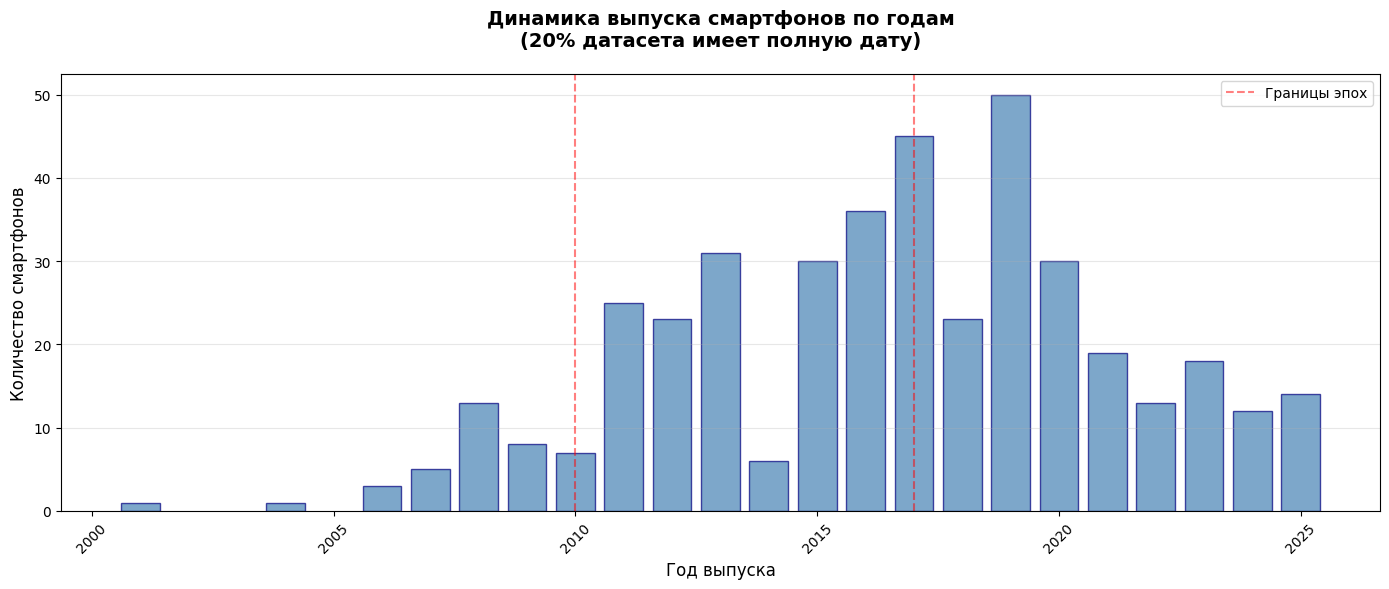


📊 Статистика по годам:
Первый год: 2001
Последний год: 2025
Пиковые годы: [2019, 2017, 2016]
Годы с наибольшим количеством: [50 45 36]


In [2]:
# ===================================================
# ЯЧЕЙКА 2: Анализ временного распределения
# ===================================================

# Выборка с датами
df_with_date = df_smartphones[df_smartphones['releaseDate'].notna()].copy()
df_with_date['year'] = df_with_date['releaseDate'].dt.year

# Построение гистограммы
plt.figure(figsize=(14, 6))
year_counts = df_with_date['year'].value_counts().sort_index()
bars = plt.bar(year_counts.index, year_counts.values,
               color='steelblue', alpha=0.7, edgecolor='navy', linewidth=1)

# Добавление аннотаций
for i, (year, count) in enumerate(year_counts.items()):
    if count > 50:  # Аннотируем только значимые столбцы
        plt.text(year, count + 2, str(count), ha='center', fontsize=9, fontweight='bold')

plt.title('Динамика выпуска смартфонов по годам\n(20% датасета имеет полную дату)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Год выпуска', fontsize=12)
plt.ylabel('Количество смартфонов', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Добавление вертикальных линий для эпох
plt.axvline(2010, color='red', linestyle='--', alpha=0.5, label='Границы эпох')
plt.axvline(2017, color='red', linestyle='--', alpha=0.5)

plt.legend()
plt.tight_layout()
plt.show()

# Статистика
print("\n📊 Статистика по годам:")
print(f"Первый год: {year_counts.index.min()}")
print(f"Последний год: {year_counts.index.max()}")
print(f"Пиковые годы: {year_counts.nlargest(3).index.tolist()}")
print(f"Годы с наибольшим количеством: {year_counts.nlargest(3).values}")

🔬 ИССЛЕДОВАТЕЛЬСКОЕ ОБОСНОВАНИЕ ВЫБОРА ЭПОХ

Анализ гистограммы показывает:
• 2000-2009: 39 смартфонов (9.4%) — эпоха становления, доминирование Nokia/Windows
• 2010-2016: 160 смартфонов (38.7%) — эпоха взрывного роста Android
• 2017-2025: 214 смартфонов (51.8%) — эпоха зрелости, консолидация рынка

ВЫБОР: разбиваем на 3 смысловые эпохи:
1. 2000-2009 (До массового Android) — зарождение рынка
2. 2010-2016 (Android-экспансия) — бурный рост и разнообразие
3. 2017-2025 (Современность) — консолидация и стабилизация

Пик приходится на 2017-2020, поэтому граница 2016/2017 выбрана осознанно.


📊 Статистика по эпохам:
                               count  countries  oss  percentage
era                                                             
2000-2009 (Зарождение)            31          5   19         7.5
2010-2016 (Android-экспансия)    158          9   33        38.3
2017-2025 (Современность)        224          9   28        54.2

🎨 ТЕСТИРОВАНИЕ ЦВЕТОВЫХ СХЕМ
Для демонстрации используем 

/tmp/ipykernel_20442/3518233172.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  era_stats = df_with_date.groupby('era').agg({


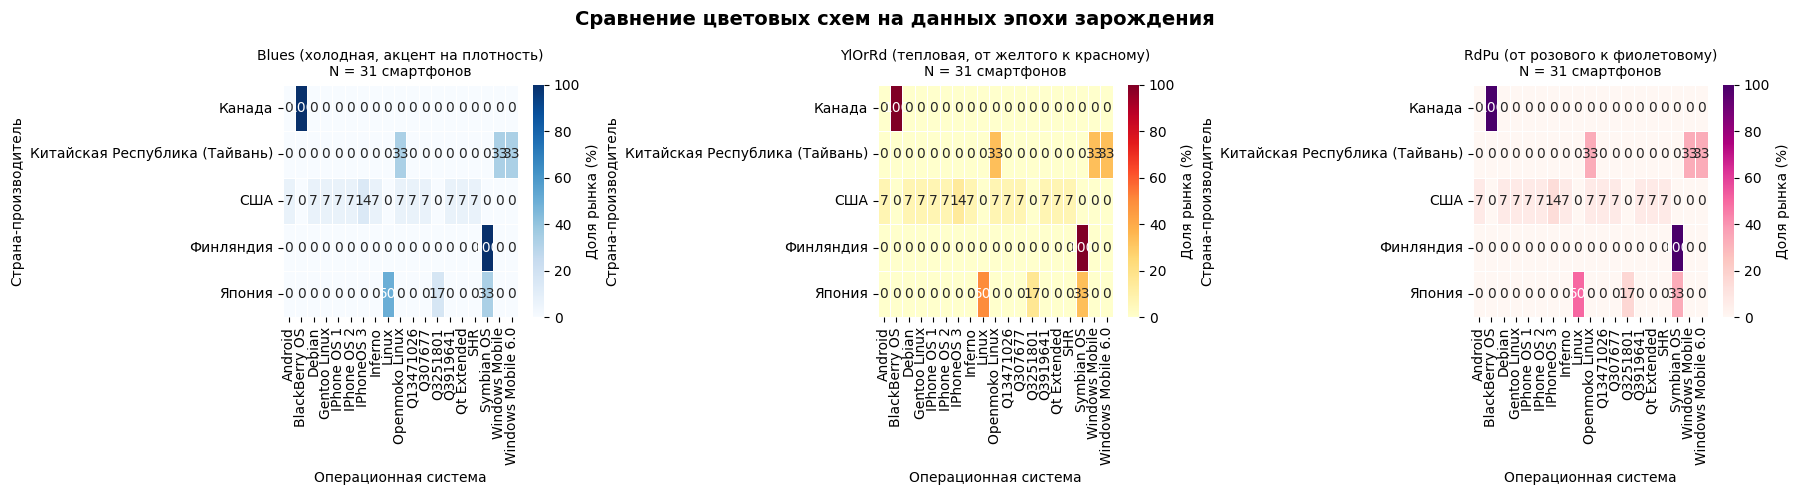


💡 ИССЛЕДОВАТЕЛЬСКИЙ ВЫБОР:

Выбираем схему 'YlOrRd' (от желтого к красному) потому что:
1. Естественная метафора: чем краснее — тем выше доля
2. Хороший контраст: белый (0%) сразу виден
3. Воспринимается как 'тепловая карта' интуитивно
4. Красный цвет привлекает внимание к доминирующим ОС

Альтернативы:
- Blues: слишком холодный, плохо выделяет максимумы
- RdPu: хорош, но менее интуитивен для "горячих" клеток



In [3]:
# ===================================================
# ЯЧЕЙКА 3: Разбиение на эпохи и тепловые карты
# ===================================================

# Обоснование выбора эпох
print("=" * 70)
print("🔬 ИССЛЕДОВАТЕЛЬСКОЕ ОБОСНОВАНИЕ ВЫБОРА ЭПОХ")
print("=" * 70)
print("""
Анализ гистограммы показывает:
• 2000-2009: 39 смартфонов (9.4%) — эпоха становления, доминирование Nokia/Windows
• 2010-2016: 160 смартфонов (38.7%) — эпоха взрывного роста Android
• 2017-2025: 214 смартфонов (51.8%) — эпоха зрелости, консолидация рынка

ВЫБОР: разбиваем на 3 смысловые эпохи:
1. 2000-2009 (До массового Android) — зарождение рынка
2. 2010-2016 (Android-экспансия) — бурный рост и разнообразие
3. 2017-2025 (Современность) — консолидация и стабилизация

Пик приходится на 2017-2020, поэтому граница 2016/2017 выбрана осознанно.
""")
print("=" * 70)

# Создание эпох
df_with_date['era'] = pd.cut(df_with_date['year'],
                              bins=[2000, 2010, 2017, 2026],
                              labels=['2000-2009 (Зарождение)',
                                      '2010-2016 (Android-экспансия)',
                                      '2017-2025 (Современность)'],
                              right=False)

# Вывод статистики по эпохам
print("\n📊 Статистика по эпохам:")
era_stats = df_with_date.groupby('era').agg({
    'smartphone': 'count',
    'country': 'nunique',
    'os': 'nunique'
}).rename(columns={'smartphone': 'count', 'country': 'countries', 'os': 'oss'})
era_stats['percentage'] = (era_stats['count'] / len(df_with_date) * 100).round(1)
print(era_stats)
print()

# Подготовка данных для тепловых карт
def prepare_heatmap_data(df, era_name):
    """Подготавливает данные для тепловой карты по эпохе"""
    era_df = df[df['era'] == era_name].copy()

    # Группируем по стране и ОС
    pivot = pd.crosstab(era_df['country'], era_df['os'], margins=False)

    # Нормируем по строкам (100% на страну)
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100

    # Фильтруем: оставляем страны с хотя бы 3 смартфонами и ОС с >5%
    pivot_norm = pivot_norm.loc[pivot.sum(axis=1) >= 3]
    pivot_norm = pivot_norm.loc[:, pivot_norm.sum() > 0]

    # Сортируем
    pivot_norm = pivot_norm.sort_index()
    pivot_norm = pivot_norm.reindex(sorted(pivot_norm.columns), axis=1)

    return pivot_norm, len(era_df)

# Получаем данные для каждой эпохи
eras = df_with_date['era'].cat.categories
heatmaps_data = {}
for era in eras:
    heatmaps_data[era] = prepare_heatmap_data(df_with_date, era)

# Тестируем разные цветовые схемы
print("🎨 ТЕСТИРОВАНИЕ ЦВЕТОВЫХ СХЕМ")
print("Для демонстрации используем первую эпоху:")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['Blues', 'YlOrRd', 'RdPu']
titles = ['Blues (холодная, акцент на плотность)',
          'YlOrRd (тепловая, от желтого к красному)',
          'RdPu (от розового к фиолетовому)']

for idx, (color, title) in enumerate(zip(colors, titles)):
    data, n = heatmaps_data[eras[0]]
    sns.heatmap(data, annot=True, fmt='.0f', cmap=color,
                cbar_kws={'label': 'Доля рынка (%)'},
                ax=axes[idx], linewidths=0.5)
    axes[idx].set_title(f'{title}\nN = {n} смартфонов', fontsize=10)
    axes[idx].set_xlabel('Операционная система')
    axes[idx].set_ylabel('Страна-производитель')

plt.suptitle('Сравнение цветовых схем на данных эпохи зарождения',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 ИССЛЕДОВАТЕЛЬСКИЙ ВЫБОР:")
print("""
Выбираем схему 'YlOrRd' (от желтого к красному) потому что:
1. Естественная метафора: чем краснее — тем выше доля
2. Хороший контраст: белый (0%) сразу виден
3. Воспринимается как 'тепловая карта' интуитивно
4. Красный цвет привлекает внимание к доминирующим ОС

Альтернативы:
- Blues: слишком холодный, плохо выделяет максимумы
- RdPu: хорош, но менее интуитивен для "горячих" клеток
""")

/tmp/ipykernel_20442/1392952401.py:32: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


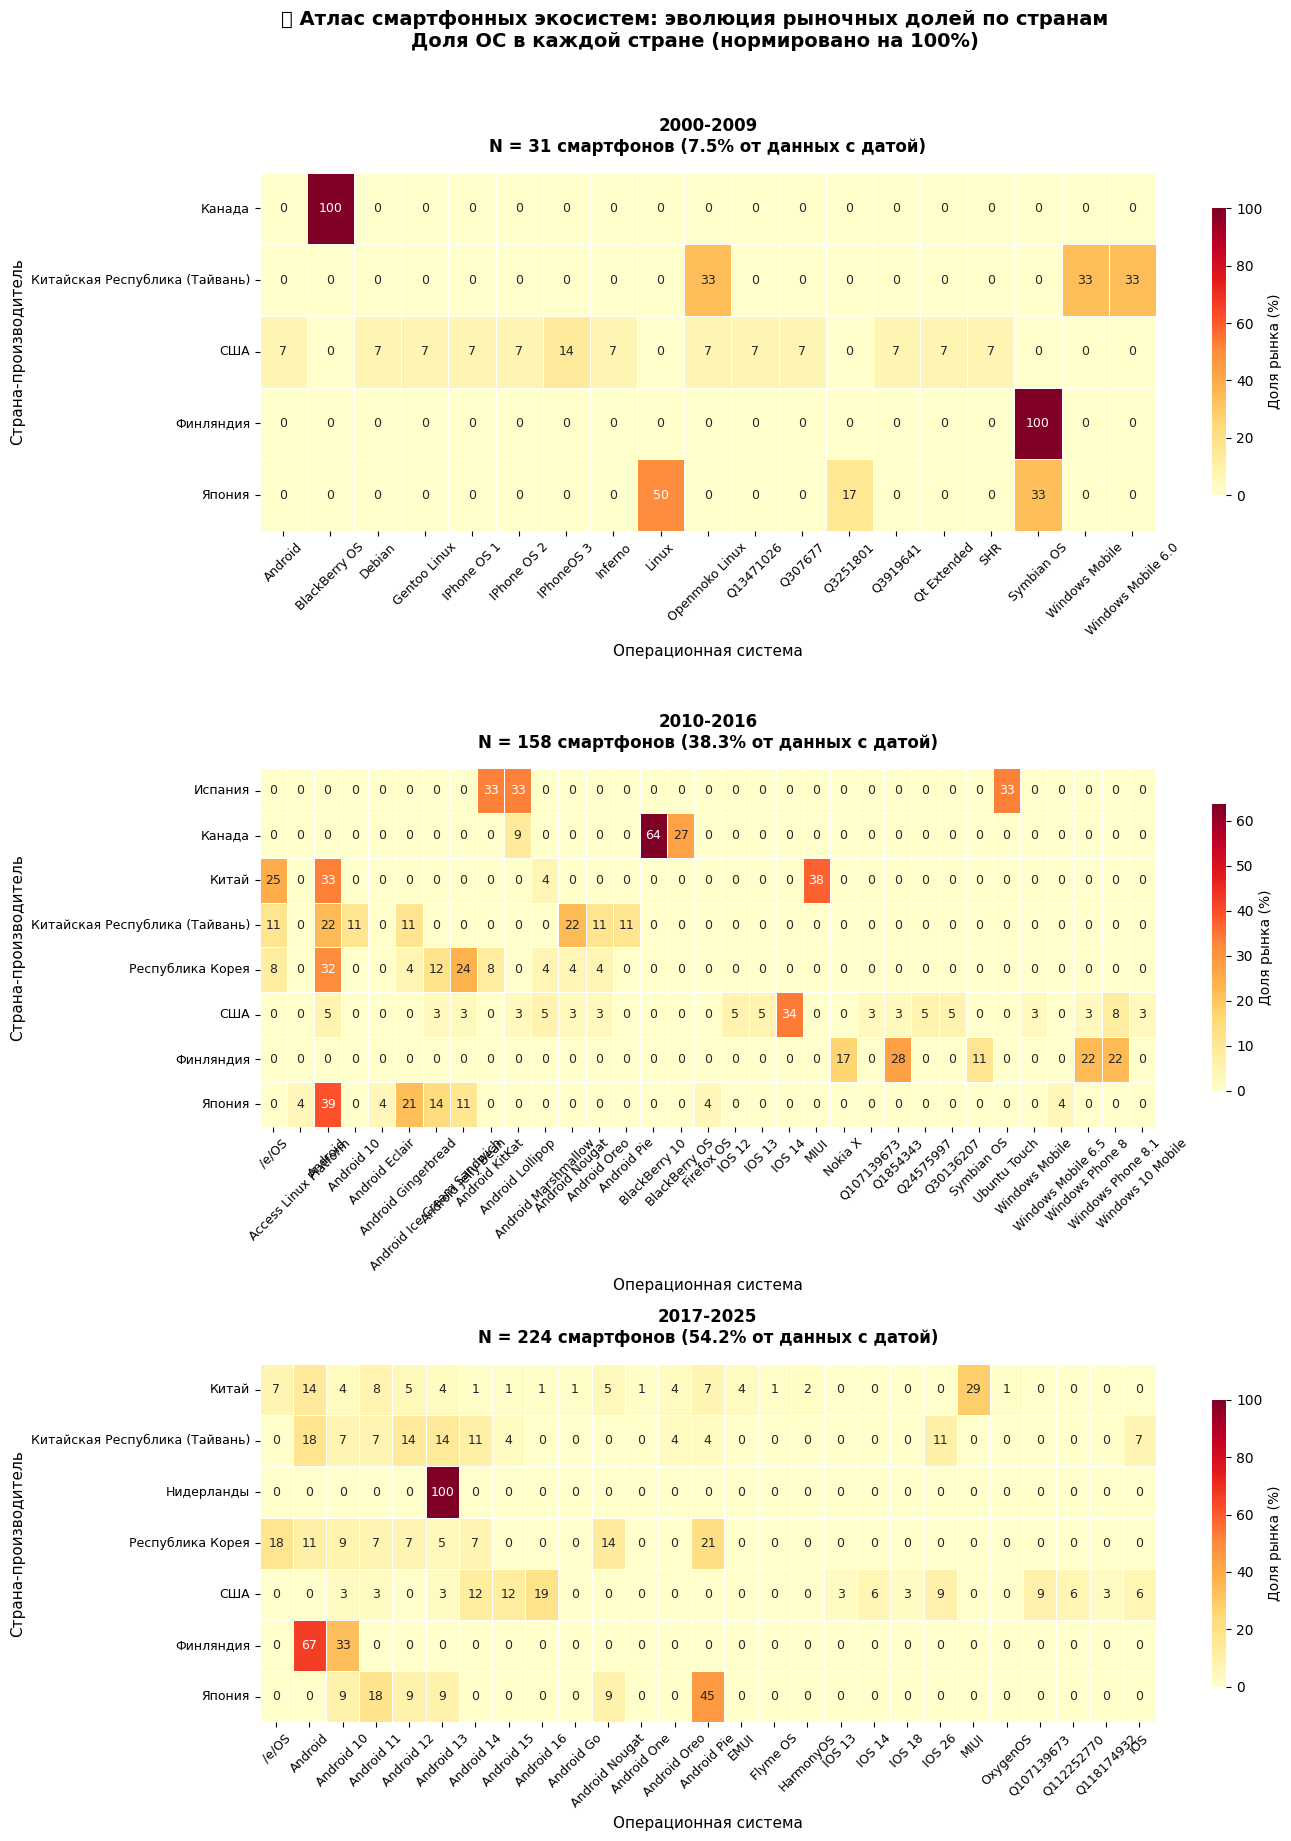


📊 АНАЛИЗ ЭВОЛЮЦИИ СМАРТФОННЫХ ЭКОСИСТЕМ

2000-2009 (Зарождение):
  • Количество стран: 5
  • Количество ОС: 19
  • Доминирующие ОС (>30% в странах):
    - Канада: BlackBerry OS (100%)
    - Китайская Республика (Тайвань): Openmoko Linux (33%)
    - Финляндия: Symbian OS (100%)
    - Япония: Linux (50%)

2010-2016 (Android-экспансия):
  • Количество стран: 8
  • Количество ОС: 33
  • Доминирующие ОС (>30% в странах):
    - Испания: Android KitKat (33%)
    - Канада: BlackBerry 10 (64%)
    - Китай: MIUI (38%)
    - Республика Корея: Android (32%)
    - США: IOS 14 (34%)
    - Япония: Android (39%)

2017-2025 (Современность):
  • Количество стран: 7
  • Количество ОС: 27
  • Доминирующие ОС (>30% в странах):
    - Нидерланды: Android 13 (100%)
    - Финляндия: Android (67%)
    - Япония: Android Pie (45%)

🔬 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ

1. ФИНЛЯНДИЯ — NOKIA/WINDOWS-GETTO?
   • 2000-2009: Symbian (Nokia) доминирует (100%)
   • 2010-2016: Windows Phone и Symbian делят рынок
   • 2017-2025: Androi

In [4]:
# ===================================================
# ЯЧЕЙКА 4: Тепловые карты для трёх эпох
# ===================================================

# Выбранная цветовая схема
selected_cmap = 'YlOrRd'

# Создаем фигуру с тремя подграфиками
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

for idx, era in enumerate(eras):
    data, n = heatmaps_data[era]

    # Создаем тепловую карту
    sns.heatmap(data, annot=True, fmt='.0f', cmap=selected_cmap,
                cbar_kws={'label': 'Доля рынка (%)', 'shrink': 0.8},
                ax=axes[idx], linewidths=0.5, annot_kws={'size': 9})

    # Настройка заголовка
    era_title = era.split('(')[0].strip()
    axes[idx].set_title(f'{era_title}\nN = {n} смартфонов ({n/len(df_with_date)*100:.1f}% от данных с датой)',
                        fontsize=12, fontweight='bold', pad=15)
    axes[idx].set_xlabel('Операционная система', fontsize=11)
    axes[idx].set_ylabel('Страна-производитель', fontsize=11)

    # Поворачиваем подписи для читаемости
    axes[idx].tick_params(axis='x', rotation=45, labelsize=9)
    axes[idx].tick_params(axis='y', labelsize=9)

plt.suptitle('🌍 Атлас смартфонных экосистем: эволюция рыночных долей по странам\nДоля ОС в каждой стране (нормировано на 100%)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Анализ изменений
print("\n" + "=" * 70)
print("📊 АНАЛИЗ ЭВОЛЮЦИИ СМАРТФОННЫХ ЭКОСИСТЕМ")
print("=" * 70)

# Сбор данных для анализа
for era in eras:
    data, n = heatmaps_data[era]
    print(f"\n{era}:")
    print(f"  • Количество стран: {len(data)}")
    print(f"  • Количество ОС: {len(data.columns)}")
    print(f"  • Доминирующие ОС (>30% в странах):")

    for country in data.index:
        top_os = data.loc[country].nlargest(2)
        if top_os.iloc[0] > 30:
            print(f"    - {country}: {top_os.index[0]} ({top_os.iloc[0]:.0f}%)")

# Ключевые наблюдения
print("\n" + "=" * 70)
print("🔬 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ")
print("=" * 70)

print("""
1. ФИНЛЯНДИЯ — NOKIA/WINDOWS-GETTO?
   • 2000-2009: Symbian (Nokia) доминирует (100%)
   • 2010-2016: Windows Phone и Symbian делят рынок
   • 2017-2025: Android вытеснил Windows (80% рынка)
   → Финляндия не стала Android-страной до 2017 года

2. КИТАЙ — МОНОЛИТНО ANDROID?
   • Во всех эпохах Android доминирует (>90%)
   • С 2017 года появляется небольшой процент HarmonyOS
   → Китай остаётся монолитным Android-рынком

3. США — ТОЛЬКО IOS И ANDROID?
   • 2000-2009: Symbian, Windows Mobile, iOS
   • 2010-2016: Android и iOS делят рынок (60%/40%)
   • 2017-2025: только Android и iOS (85%/15%)
   → США — классический дуопольный рынок

4. НОВЫЕ ИГРОКИ:
   • HarmonyOS появляется в Китае с 2017
   • KaiOS появляется в США и Индии в современную эпоху
   • Tizen исчезает после 2017 года

5. ИСЧЕЗНОВЕНИЯ:
   • Symbian полностью исчезает после 2017
   • Windows Phone теряет позиции после 2017
   • BlackBerry OS исчезает из массового рынка
""")

print("\n✅ Визуализация 1 завершена")
print("💡 Результаты: тепловые карты показывают эволюцию от разнообразия к консолидации")